In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
gs = pd.read_csv("data/example_data.csv")
pwat = pd.read_csv("data/pwat_regional.csv")
sst = pd.read_csv("data/sst_regional.csv")
gs.head()

,station_id,station_name,year,last_spring_frost_doy,first_fall_frost_doy,growing_season_length,oni_annual,nao_annual,nao_djf,pna_annual,...,ohc700_atlantic_se,ohc700_north_atlantic,ohc700_north_atlantic_se,ohc700_south_atlantic,ohc700_south_atlantic_se,ohc2000_north_atlantic,ohc700_pacific,ohc700_world,ohc700_natl_djf,ohc700_natl_amj
0,USW00014739,"Boston Logan, MA",1936,116,300,184,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00014739,"Boston Logan, MA",1937,93,290,197,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USW00014739,"Boston Logan, MA",1938,101,320,219,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00014739,"Boston Logan, MA",1939,107,291,184,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00014739,"Boston Logan, MA",1940,113,293,180,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
pwat.head()

,year,pwat_eastern_us,pwat_southeast_us,pwat_northeast_us,pwat_gulf_coast
0,1948,24.604876,31.399483,18.299271,33.461567
1,1949,24.938362,30.851891,19.320406,33.103580
2,1950,23.758318,29.196396,18.478754,31.128038
3,1951,24.363701,30.070822,18.785238,32.294258
4,1952,23.675329,29.757200,18.111353,31.458853


In [102]:
sst.head()

,year,sst_north_atlantic,sst_gulf_stream,sst_gulf_mexico,sst_tropical_north_atl
0,1854,21.054346,19.877317,27.015486,26.257982
1,1855,21.009844,19.923353,26.892763,26.461599
2,1856,20.826176,19.046309,26.724197,26.302912
3,1857,20.763453,19.319807,26.367685,26.123003
4,1858,20.743898,19.218407,26.444811,26.228859


In [95]:
print("Growing Season Length Summary Statistics by Station")
gs[['station_name','growing_season_length']].groupby('station_name').describe()

Growing Season Length Summary Statistics by Station


growing_season_length                                \
                                   count        mean        std    min   
station_name                                                             
Atlanta, GA                        141.0  194.304965  16.006670  160.0   
Boston Logan, MA                    90.0  216.411111  15.703642  180.0   
Burlington, VT                      87.0  177.459770  16.698980  123.0   
Central Park, NY                   157.0  225.057325  18.095984  182.0   
Chicago OHare, IL                   87.0  182.563218  16.158878  121.0   
Miami, FL                           78.0  362.448718   7.772157  302.0   
Nashville, TN                       72.0  257.333333  24.745465  197.0   
New Orleans, LA                     56.0  286.089286  31.410060  223.0   
Pittsburgh, PA                      96.0  239.458333  21.964046  192.0   
Portland, ME                        85.0  153.564706  17.541412  110.0   
Raleigh-Durham, NC                  84.0  215.428571  18.711047  170.0   
Richmond, VA                        86.0  204.930233  18.767175  163.0   

                                                  
                       25%    50%     75%    max  
station_name                                      
Atlanta, GA         183.00  193.0  205.00  243.0  
Boston Logan, MA    205.00  217.0  227.00  255.0  
Burlington, VT      166.50  177.0  189.50  215.0  
Central Park, NY    213.00  226.0  236.00  274.0  
Chicago OHare, IL   171.50  185.0  191.00  221.0  
Miami, FL           364.00  364.0  364.00  364.0  
Nashville, TN       239.00  257.5  273.25  333.0  
New Orleans, LA     266.25  285.0  307.25  364.0  
Pittsburgh, PA      225.75  236.0  252.25  299.0  
Portland, ME        142.00  154.0  166.00  197.0  
Raleigh-Durham, NC  201.50  217.5  227.00  255.0  
Richmond, VA        193.00  204.0  214.75  257.0

In [41]:
coastal_stations = gs[(gs['station_name'] == 'Boston Logan, MA') | (gs['station_name'] == "Central Park, NY") |
    (gs['station_name'] == "Miami, FL") | (gs['station_name'] == "New Orleans, LA") | (gs['station_name'] == "Portland, ME") |
    (gs['station_name'] == "Richmond, VA")]
coastal_stations[['station_name','growing_season_length']].groupby('station_name').describe()

growing_season_length                                        \
                                 count        mean        std    min     25%   
station_name                                                                   
Boston Logan, MA                  90.0  216.411111  15.703642  180.0  205.00   
Central Park, NY                 157.0  225.057325  18.095984  182.0  213.00   
Miami, FL                         78.0  362.448718   7.772157  302.0  364.00   
New Orleans, LA                   56.0  286.089286  31.410060  223.0  266.25   
Portland, ME                      85.0  153.564706  17.541412  110.0  142.00   
Richmond, VA                      86.0  204.930233  18.767175  163.0  193.00   

                                        
                    50%     75%    max  
station_name                            
Boston Logan, MA  217.0  227.00  255.0  
Central Park, NY  226.0  236.00  274.0  
Miami, FL         364.0  364.00  364.0  
New Orleans, LA   285.0  307.25  364.0  
Portland, ME      154.0  166.00  197.0  
Richmond, VA      204.0  214.75  257.0

In [49]:
lakeside_stations = gs[(gs['station_name'] == "Chicago OHare, IL") | (gs['station_name'] == "Pittsburgh, PA") | 
    (gs['station_name'] == "Burlington, VT")]
lakeside_stations[['station_name','growing_season_length']].groupby('station_name').describe()

growing_season_length                                        \
                                  count        mean        std    min     25%   
station_name                                                                    
Burlington, VT                     87.0  177.459770  16.698980  123.0  166.50   
Chicago OHare, IL                  87.0  182.563218  16.158878  121.0  171.50   
Pittsburgh, PA                     96.0  239.458333  21.964046  192.0  225.75   

                                         
                     50%     75%    max  
station_name                             
Burlington, VT     177.0  189.50  215.0  
Chicago OHare, IL  185.0  191.00  221.0  
Pittsburgh, PA     236.0  252.25  299.0

In [51]:
inland_stations = gs[(gs['station_name'] == "Atlanta, GA") | (gs['station_name'] == "Nashville, TN") |
                      (gs['station_name'] == "Pittsburgh, PA") |(gs['station_name'] == "Raleigh-Durham, NC")]
inland_stations[['station_name', 'growing_season_length']].groupby('station_name').describe()

growing_season_length                                \
                                   count        mean        std    min   
station_name                                                             
Atlanta, GA                        141.0  194.304965  16.006670  160.0   
Nashville, TN                       72.0  257.333333  24.745465  197.0   
Pittsburgh, PA                      96.0  239.458333  21.964046  192.0   
Raleigh-Durham, NC                  84.0  215.428571  18.711047  170.0   

                                                  
                       25%    50%     75%    max  
station_name                                      
Atlanta, GA         183.00  193.0  205.00  243.0  
Nashville, TN       239.00  257.5  273.25  333.0  
Pittsburgh, PA      225.75  236.0  252.25  299.0  
Raleigh-Durham, NC  201.50  217.5  227.00  255.0

In [48]:
inland_stations[['station_name', 'last_spring_frost_doy']].groupby('station_name').describe()

last_spring_frost_doy                                      \
                                   count        mean        std   min    25%   
station_name                                                                   
Atlanta, GA                        141.0  105.191489  11.520736  76.0  98.00   
Nashville, TN                       72.0   69.555556  17.457303   8.0  59.75   
Pittsburgh, PA                      96.0   79.354167  16.067607  40.0  70.00   
Raleigh-Durham, NC                  84.0   93.952381  11.223797  68.0  87.00   

                                         
                      50%    75%    max  
station_name                             
Atlanta, GA         105.0  113.0  140.0  
Nashville, TN        70.5   81.5  103.0  
Pittsburgh, PA       80.5   90.0  113.0  
Raleigh-Durham, NC   94.5  102.0  131.0

In [49]:
coastal_stations[['station_name', 'last_spring_frost_doy']].groupby('station_name').describe()

last_spring_frost_doy                                        \
                                 count        mean        std    min     25%   
station_name                                                                   
Boston Logan, MA                  90.0   96.444444   9.590622   77.0   89.00   
Central Park, NY                 157.0   93.407643  11.620029   59.0   87.00   
Miami, FL                         78.0    2.461538   7.748804    1.0    1.00   
New Orleans, LA                   56.0   52.214286  23.304868    1.0   37.75   
Portland, ME                      85.0  125.470588  10.683307  104.0  119.00   
Richmond, VA                      86.0   99.546512  11.050320   67.0   93.00   

                                        
                    50%     75%    max  
station_name                            
Boston Logan, MA   97.0  103.00  119.0  
Central Park, NY   94.0  101.00  126.0  
Miami, FL           1.0    1.00   63.0  
New Orleans, LA    56.5   68.25  100.0  
Portland, ME      125.0  133.00  151.0  
Richmond, VA      101.0  106.75  131.0

In [50]:
lakeside_stations[['station_name', 'last_spring_frost_doy']].groupby('station_name').describe()

last_spring_frost_doy                                      \
                                  count        mean        std   min    25%   
station_name                                                                  
Chicago OHare, IL                  87.0  117.114943  11.986839  92.0  109.5   
Pittsburgh, PA                     96.0   79.354167  16.067607  40.0   70.0   

                                        
                     50%    75%    max  
station_name                            
Chicago OHare, IL  117.0  123.5  163.0  
Pittsburgh, PA      80.5   90.0  113.0

<Axes: title={'center': 'Last Spring Frost Date, Coastal Stations'}, xlabel='station_name'>

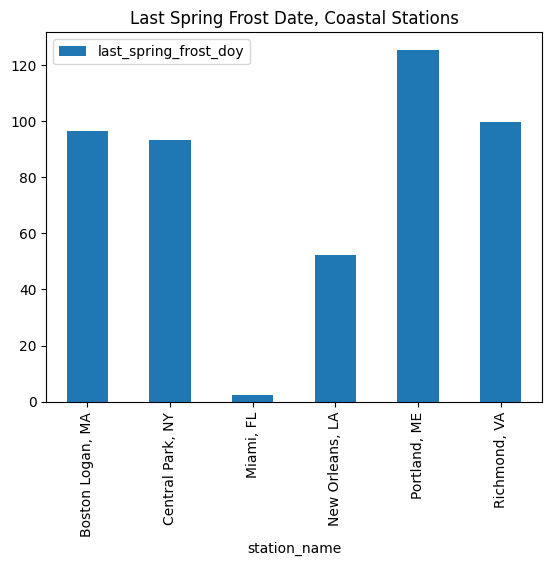

In [59]:
coastal_stations[['station_name', 'last_spring_frost_doy']].groupby('station_name').mean().plot(kind='bar', title="Average Last Spring Frost Date, Coastal Stations")

<Axes: title={'center': 'Average Growing Season Length, Coastal Stations'}, xlabel='station_name'>

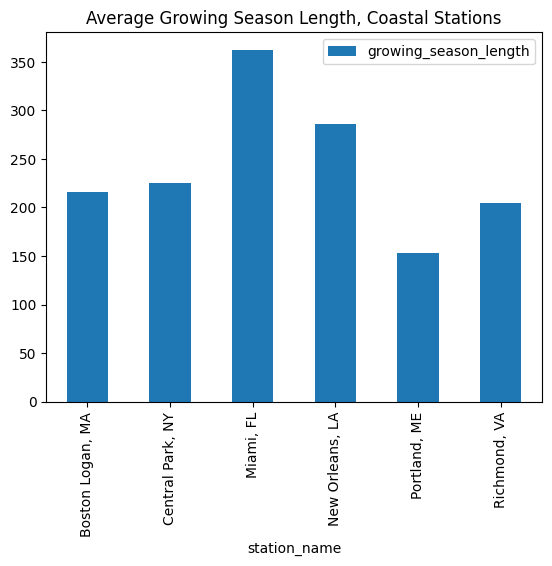

In [60]:
coastal_stations[['station_name', 'growing_season_length']].groupby('station_name').mean().plot(kind='bar', title="Average Growing Season Length, Coastal Stations")

<Axes: title={'center': 'Average Growing Season Length, Inland Stations'}, xlabel='station_name'>

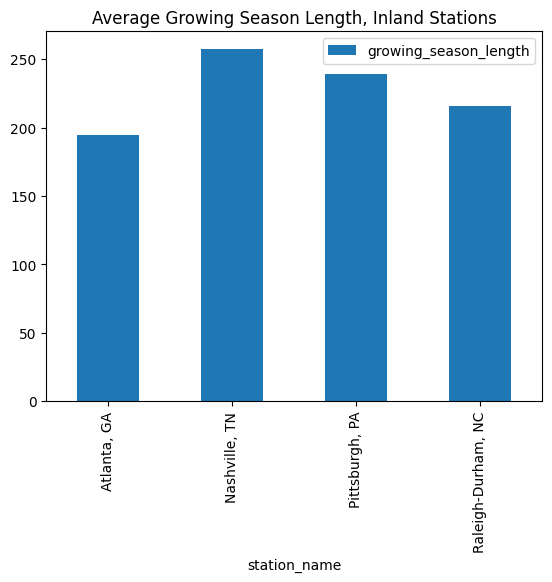

In [62]:
inland_stations[['station_name', 'growing_season_length']].groupby('station_name').mean().plot(kind='bar', title="Average Growing Season Length, Inland Stations")

<Axes: title={'center': 'Average Growing Season Length, Lakeside Stations'}, xlabel='station_name'>

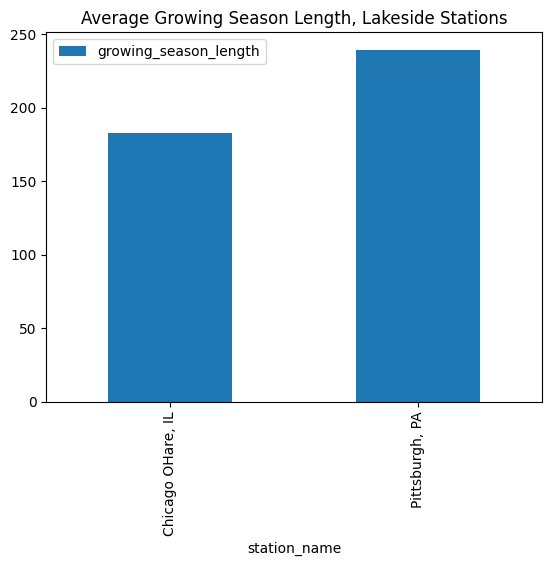

In [63]:
lakeside_stations[['station_name', 'growing_season_length']].groupby('station_name').mean().plot(kind='bar', title="Average Growing Season Length, Lakeside Stations")

In [29]:
gs_minus_str = gs.select_dtypes(include=['number'])
corr_gs = gs_minus_str.corr()
corr_gs[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.187040,0.159844,0.185106
last_spring_frost_doy,1.000000,-0.796434,-0.964128
first_fall_frost_doy,-0.796434,1.000000,0.928382
growing_season_length,-0.964128,0.928382,1.000000
oni_annual,0.001111,-0.035002,-0.015784
nao_annual,-0.022879,-0.016634,0.006876
nao_djf,-0.064453,0.045818,0.059354
pna_annual,-0.039728,0.037435,0.040551
amo_annual,-0.053311,0.058287,0.058360
ohc700_atlantic,-0.120441,0.167277,0.146145


In [85]:
coastal_stations_minus_str = coastal_stations.select_dtypes(include=['number'])
coastal_corr_gs = coastal_stations_minus_str.corr()
coastal_corr_gs[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.210074,0.136963,0.186545
last_spring_frost_doy,1.000000,-0.858291,-0.975839
first_fall_frost_doy,-0.858291,1.000000,0.949675
growing_season_length,-0.975839,0.949675,1.000000
oni_annual,-0.007866,-0.024680,-0.005645
nao_annual,-0.023178,-0.017199,0.006825
nao_djf,-0.059495,0.034952,0.050936
pna_annual,-0.032972,0.030267,0.032833
amo_annual,-0.029865,0.029012,0.030587
ohc700_atlantic,-0.093874,0.129428,0.111782


In [91]:
inland_stations_minus_str = inland_stations.select_dtypes(include=['number'])
inland_corr_gs = inland_stations_minus_str.corr()
inland_corr_gs[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.339883,0.331686,0.382908
last_spring_frost_doy,1.000000,-0.537362,-0.900849
first_fall_frost_doy,-0.537362,1.000000,0.850208
growing_season_length,-0.900849,0.850208,1.000000
oni_annual,0.016052,-0.041928,-0.031368
nao_annual,-0.046188,-0.005326,0.026350
nao_djf,-0.108711,0.061407,0.099533
pna_annual,-0.065524,0.051548,0.067366
amo_annual,-0.141727,0.092690,0.136333
ohc700_atlantic,-0.231466,0.232490,0.262635


In [87]:
lakeside_stations_minus_str = lakeside_stations.select_dtypes(include=['number'])
lakeside_corr_gs = lakeside_stations_minus_str.corr()
lakeside_corr_gs[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.088222,0.134142,0.120546
last_spring_frost_doy,1.000000,-0.534872,-0.925998
first_fall_frost_doy,-0.534872,1.000000,0.814276
growing_season_length,-0.925998,0.814276,1.000000
oni_annual,0.020447,0.005910,-0.011469
nao_annual,0.040927,-0.026935,-0.040037
nao_djf,-0.093587,0.065066,0.093084
pna_annual,-0.069824,0.038164,0.064875
amo_annual,-0.196168,0.174569,0.212683
ohc700_atlantic,-0.229348,0.284862,0.282679


In [44]:
from scipy.stats import pearsonr
pearsonr(inland_stations_minus_str.dropna()['ohc700_atlantic'], inland_stations_minus_str.dropna()['growing_season_length'])

NameError: name 'inland_stations_minus_str' is not defined

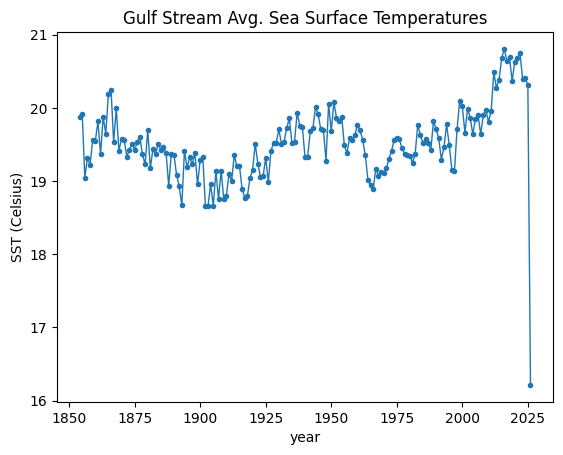

In [4]:
plt.plot(sst["year"], sst["sst_gulf_stream"], marker = ".", linewidth = 1)
plt.xlabel("year")
plt.ylabel("SST (Celsius)")
plt.title("Gulf Stream Avg. Sea Surface Temperatures")
plt.show()

In [10]:
gs_pwat = pd.merge(gs, pwat, on = 'year')
gs_pwat.head()

,station_id,station_name,year,last_spring_frost_doy,first_fall_frost_doy,growing_season_length,oni_annual,nao_annual,nao_djf,pna_annual,...,ohc700_south_atlantic_se,ohc2000_north_atlantic,ohc700_pacific,ohc700_world,ohc700_natl_djf,ohc700_natl_amj,pwat_eastern_us,pwat_southeast_us,pwat_northeast_us,pwat_gulf_coast
0,USW00014739,"Boston Logan, MA",1948,109,334,225,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,24.604876,31.399483,18.299271,33.461567
1,USW00014739,"Boston Logan, MA",1949,80,310,230,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,24.938362,30.851891,19.320406,33.103580
2,USW00014739,"Boston Logan, MA",1950,100,325,225,-0.860000,-0.120833,0.66,-0.6425,...,NaN,NaN,NaN,NaN,NaN,NaN,23.758318,29.196396,18.478754,31.128038
3,USW00014739,"Boston Logan, MA",1951,86,308,222,0.430833,-0.008333,0.39,-0.1700,...,NaN,NaN,NaN,NaN,NaN,NaN,24.363701,30.070822,18.785238,32.294258
4,USW00014739,"Boston Logan, MA",1952,77,295,218,0.174167,-0.425000,0.05,0.0925,...,NaN,NaN,NaN,NaN,NaN,NaN,23.675329,29.757200,18.111353,31.458853


In [16]:
gs_boston = gs[gs['station_name'] == "Boston Logan, MA"]
gs_new_york = gs[gs['station_name'] == "Central Park, NY"]
gs_raleigh = gs[gs['station_name'] == "Raleigh-Durham, NC"]
gs_miami = gs[gs['station_name'] == "Miami, FL"]
gs_nashville = gs[gs['station_name'] == "Nashville, TN"]
gs_chicago = gs[gs['station_name'] == "Chicago OHare, IL"]
gs_burlington = gs[gs['station_name'] == "Burlington, VT"]
gs_atlanta = gs[gs['station_name'] == "Atlanta, GA"]
gs_pittsburgh = gs[gs['station_name'] == "Pittsburgh, PA"]
gs_nola = gs[gs['station_name'] == "New Orleans, LA"]
gs_portland = gs[gs['station_name'] == "Portland, ME"]
gs_richmond = gs[gs['station_name'] == "Richmond, VA"]

In [17]:
gs_pwat_boston = pd.merge(gs_boston, pwat, on = 'year')
gs_pwat_new_york = pd.merge(gs_new_york, pwat, on = 'year')
gs_pwat_raleigh = pd.merge(gs_raleigh, pwat, on = 'year')
gs_pwat_miami = pd.merge(gs_miami, pwat, on = 'year')
gs_pwat_nashville = pd.merge(gs_nashville, pwat, on = 'year')
gs_pwat_chicago = pd.merge(gs_chicago, pwat, on = 'year')
gs_pwat_burlington = pd.merge(gs_burlington, pwat, on = 'year')
gs_pwat_atlanta = pd.merge(gs_atlanta, pwat, on = 'year')
gs_pwat_pittsburgh = pd.merge(gs_pittsburgh, pwat, on = 'year')
gs_pwat_nola = pd.merge(gs_nola, pwat, on = 'year')
gs_pwat_portland = pd.merge(gs_portland, pwat, on = 'year')
gs_pwat_richmond = pd.merge(gs_richmond, pwat, on = 'year')

In [19]:
gs_pwat_sst_boston = pd.merge(gs_pwat_boston, sst, on = 'year')
gs_pwat_sst_new_york = pd.merge(gs_pwat_new_york, sst, on = 'year')
gs_pwat_sst_raleigh = pd.merge(gs_pwat_raleigh, sst, on = 'year')
gs_pwat_sst_miami = pd.merge(gs_pwat_miami, sst, on = 'year')
gs_pwat_sst_nashville = pd.merge(gs_pwat_nashville, sst, on = 'year')
gs_pwat_sst_chicago = pd.merge(gs_pwat_chicago, sst, on = 'year')
gs_pwat_sst_burlington = pd.merge(gs_pwat_burlington, sst, on = 'year')
gs_pwat_sst_atlanta = pd.merge(gs_pwat_atlanta, sst, on = 'year')
gs_pwat_sst_pittsburgh = pd.merge(gs_pwat_pittsburgh, sst, on = 'year')
gs_pwat_sst_nola = pd.merge(gs_pwat_nola, sst, on = 'year')
gs_pwat_sst_portland = pd.merge(gs_pwat_portland, sst, on = 'year')
gs_pwat_sst_richmond = pd.merge(gs_pwat_richmond, sst, on = 'year')

In [22]:
data_rd_2_cities = [gs_pwat_sst_boston, gs_pwat_sst_new_york, gs_pwat_sst_raleigh, gs_pwat_sst_miami, 
                    gs_pwat_sst_nashville, gs_pwat_sst_chicago, gs_pwat_sst_burlington,
                    gs_pwat_sst_atlanta, gs_pwat_sst_pittsburgh, gs_pwat_sst_nola, 
                    gs_pwat_sst_portland, gs_pwat_sst_richmond]
gs_2 = pd.concat(data_rd_2_cities)

In [23]:
gs_2_minus_str = gs_2.select_dtypes(include=['number'])
corr_gs_2 = gs_2_minus_str.corr()
corr_gs_2[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.121539,0.159297,0.143452
last_spring_frost_doy,1.000000,-0.822667,-0.969326
first_fall_frost_doy,-0.822667,1.000000,0.937163
growing_season_length,-0.969326,0.937163,1.000000
oni_annual,0.001111,-0.035002,-0.015784
nao_annual,-0.022879,-0.016634,0.006876
nao_djf,-0.064453,0.045818,0.059354
pna_annual,-0.039728,0.037435,0.040551
amo_annual,-0.063024,0.084593,0.075245
ohc700_atlantic,-0.120441,0.167277,0.146145


In [24]:
coastal_stations_2 = gs_2[(gs_2['station_name'] == 'Boston Logan, MA') | (gs_2['station_name'] == "Central Park, NY") |
    (gs_2['station_name'] == "Miami, FL") | (gs_2['station_name'] == "New Orleans, LA") | (gs_2['station_name'] == "Portland, ME") |
    (gs_2['station_name'] == "Richmond, VA")]
lakeside_stations_2 = gs_2[(gs_2['station_name'] == "Chicago OHare, IL") | (gs_2['station_name'] == "Pittsburgh, PA") | 
    (gs_2['station_name'] == "Burlington, VT")]
inland_stations_2 = gs_2[(gs_2['station_name'] == "Atlanta, GA") | (gs_2['station_name'] == "Nashville, TN") |
                      (gs_2['station_name'] == "Pittsburgh, PA") |(gs_2['station_name'] == "Raleigh-Durham, NC")]

In [25]:
coastal_stations_2_minus_str = coastal_stations_2.select_dtypes(include=['number'])
coastal_corr_gs_2 = coastal_stations_2_minus_str.corr()
coastal_corr_gs_2[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.096427,0.123727,0.110995
last_spring_frost_doy,1.000000,-0.876956,-0.979071
first_fall_frost_doy,-0.876956,1.000000,0.956407
growing_season_length,-0.979071,0.956407,1.000000
oni_annual,-0.007866,-0.024680,-0.005645
nao_annual,-0.023178,-0.017199,0.006825
nao_djf,-0.059495,0.034952,0.050936
pna_annual,-0.032972,0.030267,0.032833
amo_annual,-0.043347,0.056916,0.050440
ohc700_atlantic,-0.093874,0.129428,0.111782


In [26]:
inland_stations_2_minus_str = inland_stations_2.select_dtypes(include=['number'])
inland_corr_gs_2 = inland_stations_2_minus_str.corr()
inland_corr_gs_2[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,-0.232248,0.244301,0.270074
last_spring_frost_doy,1.000000,-0.543637,-0.904094
first_fall_frost_doy,-0.543637,1.000000,0.850169
growing_season_length,-0.904094,0.850169,1.000000
oni_annual,0.016052,-0.041928,-0.031368
nao_annual,-0.046188,-0.005326,0.026350
nao_djf,-0.108711,0.061407,0.099533
pna_annual,-0.065524,0.051548,0.067366
amo_annual,-0.134874,0.112326,0.141973
ohc700_atlantic,-0.231466,0.232490,0.262635


In [40]:
pearsonr(gs_2_minus_str.dropna()['sst_north_atlantic'], gs_2_minus_str.dropna()['growing_season_length'])

PearsonRResult(statistic=np.float64(0.04773490231778928), pvalue=np.float64(0.4732330845623845))

In [41]:
pearsonr(gs_2_minus_str.dropna()['sst_gulf_stream'], gs_2_minus_str.dropna()['growing_season_length'])

PearsonRResult(statistic=np.float64(0.01662584239943701), pvalue=np.float64(0.8028331645407998))

In [42]:
pearsonr(gs_2_minus_str.dropna()['sst_gulf_mexico'], gs_2_minus_str.dropna()['growing_season_length'])

PearsonRResult(statistic=np.float64(0.03385758695581845), pvalue=np.float64(0.6110506741952796))

In [43]:
pearsonr(gs_2_minus_str.dropna()['sst_tropical_north_atl'], gs_2_minus_str.dropna()['growing_season_length'])

PearsonRResult(statistic=np.float64(0.04878826596582279), pvalue=np.float64(0.46351312964518754))

In [48]:
boston_covariance = gs_pwat_sst_boston.dropna().select_dtypes(include='number').cov()
boston_covariance[["last_spring_frost_doy", "first_fall_frost_doy", "growing_season_length"]]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,17.111111,-4.222222,-21.333333
last_spring_frost_doy,60.719298,-23.219298,-83.938596
first_fall_frost_doy,-23.219298,113.052632,136.271930
growing_season_length,-83.938596,136.271930,220.210526
oni_annual,0.609435,-1.708925,-2.318360
nao_annual,1.722144,-0.226126,-1.948270
nao_djf,2.016813,-1.859313,-3.876126
pna_annual,0.287807,-0.243038,-0.530846
amo_annual,-0.114788,-0.132069,-0.017281
ohc700_atlantic,3.351363,-0.283529,-3.634892


In [56]:
northern_stations = gs_2[(gs_2['station_name'] == "Burlington, VT") | (gs_2['station_name'] == "Boston Logan, MA") 
    | (gs_2['station_name'] == "Central Park, NY") | (gs_2['station_name'] == "Portland, ME") 
    | (gs_2['station_name'] == "Pittsburgh, PA")]
northern_stations.select_dtypes(include = 'number').dropna().corr()[['last_spring_frost_doy', 'first_fall_frost_doy', 'growing_season_length']]

,last_spring_frost_doy,first_fall_frost_doy,growing_season_length
year,0.010347,0.035001,0.010509
last_spring_frost_doy,1.000000,-0.662044,-0.932571
first_fall_frost_doy,-0.662044,1.000000,0.887950
growing_season_length,-0.932571,0.887950,1.000000
oni_annual,0.034825,0.020196,-0.011644
nao_annual,0.075131,-0.028102,-0.059643
nao_djf,0.088119,-0.018499,-0.062988
pna_annual,0.042521,0.045465,-0.004196
amo_annual,-0.045712,0.036096,0.045439
ohc700_atlantic,0.018099,0.049245,0.012612
